# FASE 2 — Demonstração: Otimização de Modelos de Diagnóstico de PCOS

**Tech Challenge — Grupo 62 | FIAP Pós-Graduação em Inteligência Artificial**

Este notebook demonstra os principais resultados da Fase 2:

1. **Modelos baseline** exportados da Fase 1
2. **Algoritmo Genético** — 3 experimentos com configurações distintas
3. **Comparativo de desempenho** — baseline vs. modelos otimizados
4. **Integração com LLM** — geração de explicações clínicas em linguagem natural
5. **Avaliação qualitativa** das respostas geradas

## 0. Configuração do ambiente

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

REPO_ROOT = Path('..').resolve()
MODELS_DIR = REPO_ROOT / 'models'
RESULTS_DIR = REPO_ROOT / 'results'
LLM_OUTPUTS_DIR = REPO_ROOT / 'llm_outputs'
DATASET_PATH = REPO_ROOT.parent / 'FASE_1' / 'data' / 'PCOS_data_without_infertility.xlsx'
RANDOM_STATE = 42
TARGET = 'PCOS (Y/N)'
DROP_COLS = ['Sl. No', 'Patient File No.', 'Unnamed: 44']

print('Diretórios configurados:')
print(f'  Models : {MODELS_DIR}')
print(f'  Results: {RESULTS_DIR}')
print(f'  Dataset: {DATASET_PATH}')

Diretórios configurados:
  Models : C:\repositorios\tech-challenge-group-62\FASE_2\models
  Results: C:\repositorios\tech-challenge-group-62\FASE_2\results
  Dataset: C:\repositorios\tech-challenge-group-62\FASE_1\data\PCOS_data_without_infertility.xlsx


## 1. Carregamento do dataset e modelos baseline

In [2]:
def load_dataset(path):
    df = pd.read_excel(path, sheet_name='Full_new')
    cols = [c for c in DROP_COLS if c in df.columns]
    if cols:
        df = df.drop(columns=cols)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    null_cols = df.columns[df.isnull().any()].tolist()
    if null_cols:
        imp = SimpleImputer(strategy='median')
        df[null_cols] = imp.fit_transform(df[null_cols]) # type: ignore
    return df

df = load_dataset(DATASET_PATH)
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Dataset: {df.shape[0]} pacientes, {df.shape[1]} variáveis')
print(f'Treino : {len(X_train)} amostras | Teste: {len(X_test)} amostras')
print(f'Distribuição de classes (teste):')
print(y_test.value_counts().rename({0: 'Sem PCOS', 1: 'Com PCOS'}).to_string())

Dataset: 541 pacientes, 42 variáveis
Treino : 432 amostras | Teste: 109 amostras
Distribuição de classes (teste):
PCOS (Y/N)
Sem PCOS    73
Com PCOS    36


### 1.1 Métricas dos modelos baseline (Fase 1)

In [3]:
with open(MODELS_DIR / 'baseline_metadata.json', encoding='utf-8') as f:
    meta = json.load(f)

baseline_df = pd.DataFrame([
    {'Modelo': 'Regressão Logística', 'F1-Score': meta['test_metrics']['lr_test_f1']},
    {'Modelo': 'KNN (k=7)',           'F1-Score': meta['test_metrics']['knn_test_f1']},
    {'Modelo': 'Árvore de Decisão',   'F1-Score': meta['test_metrics']['dt_test_f1']},
])
baseline_df['F1-Score'] = baseline_df['F1-Score'].round(4)
print('Modelos baseline (Fase 1):')
print(baseline_df.to_string(index=False))

Modelos baseline (Fase 1):
             Modelo  F1-Score
Regressão Logística    0.8219
          KNN (k=7)    0.7119
  Árvore de Decisão    0.7246


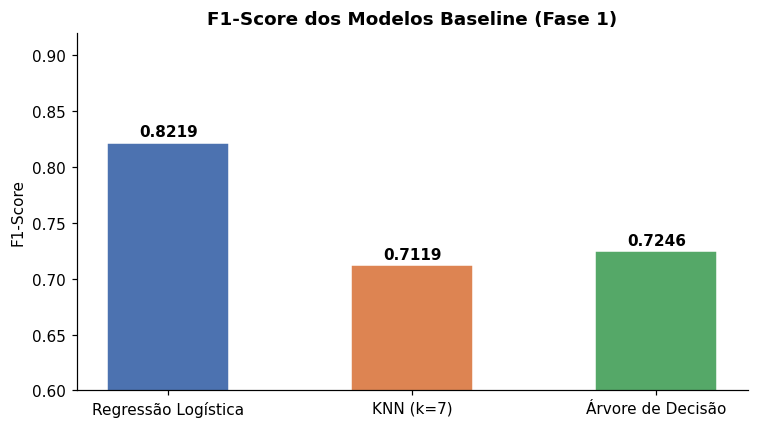

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#4C72B0', '#DD8452', '#55A868']
bars = ax.bar(baseline_df['Modelo'], baseline_df['F1-Score'], color=colors, edgecolor='white', width=0.5)
ax.set_ylim(0.6, 0.92)
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score dos Modelos Baseline (Fase 1)', fontweight='bold')
for bar, val in zip(bars, baseline_df['F1-Score']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 2. Algoritmo Genético — 3 Experimentos

### 2.1 Configurações dos experimentos

In [ ]:
configs = pd.DataFrame([
    {'Experimento': 'high_mut_uniform', 'População': 100, 'Gerações': 20,
     'Tx. Mutação': 0.50, 'Tx. Cruzamento': 0.70, 'Tipo Cruzamento': 'Uniforme', 'Early Stop Patience': 4},
    {'Experimento': 'low_mut_onepoint',  'População': 100, 'Gerações': 10,
     'Tx. Mutação': 0.20, 'Tx. Cruzamento': 0.80, 'Tipo Cruzamento': 'Um ponto', 'Early Stop Patience': 5},
    {'Experimento': 'balanced_config',    'População': 100, 'Gerações': 20,
     'Tx. Mutação': 0.30, 'Tx. Cruzamento': 0.75, 'Tipo Cruzamento': 'Uniforme', 'Early Stop Patience': 5},
])
print('Configurações dos experimentos GA:')
print(configs.to_string(index=False))

Configurações dos experimentos GA:
     Experimento  População  Gerações  Tx. Mutação  Tx. Cruzamento Tipo Cruzamento  Early Stop Patience
high_mut_uniform        100        20          0.5            0.70        Uniforme                    4
low_mut_onepoint        100        10          0.2            0.80        Um ponto                    5
 balanced_config        100        20          0.3            0.75        Uniforme                    5


### 2.2 Codificação dos genes

Cada indivíduo é um vetor de 4 genes:

| Gene | Parâmetro | Espaço | Decodificação |
|---|---|---|---|
| `gene_log10_c` | Regularização C | `[-2.0, 1.0]` contínuo | `C = 10^gene` |
| `gene_penalty` | Tipo de penalidade | `{0, 1}` binário | `0→l1`, `1→l2` |
| `gene_class_weight` | Peso de classes | `{0, 1}` binário | `0→None`, `1→balanced` |
| `gene_threshold` | Limiar de decisão | `[0.3, 0.7]` contínuo | Threshold em `predict_proba` |

**Função Fitness:**
```
fitness = 0.4 × recall  +  0.2 × especificidade  +  0.3 × F1  −  0.1 × disparidade_demográfica
```

### 2.3 Resultados dos experimentos

In [6]:
ga_results = pd.read_csv(RESULTS_DIR / 'ga_experiments.csv')

display_cols = ['exp_id', 'mutation_rate', 'crossover_rate', 'crossover_type',
                'best_fitness', 'test_recall', 'test_specificity', 'test_f1',
                'test_disparity', 'runtime_seconds']
display_df = ga_results[display_cols].copy()
display_df.columns = ['Experimento', 'Tx. Mutação', 'Tx. Cruzamento', 'Tipo Cruzamento',
                      'Fitness', 'Recall', 'Especificidade', 'F1', 'Disparidade', 'Tempo (s)']
for col in ['Fitness', 'Recall', 'Especificidade', 'F1', 'Disparidade']:
    display_df[col] = display_df[col].round(4)
display_df['Tempo (s)'] = display_df['Tempo (s)'].round(1)

print('Resultados dos 3 experimentos GA:')
print(display_df.to_string(index=False))

Resultados dos 3 experimentos GA:
     Experimento  Tx. Mutação  Tx. Cruzamento Tipo Cruzamento  Fitness  Recall  Especificidade     F1  Disparidade  Tempo (s)
high_mut_uniform          0.5            0.70         uniform   0.7814  0.8611          0.9452 0.8732       0.0065       66.4
low_mut_onepoint          0.2            0.80       one_point   0.7785  0.8611          0.9315 0.8611       0.0065       66.2
 balanced_config          0.3            0.75         uniform   0.7797  0.8611          0.9452 0.8732       0.0065       68.6


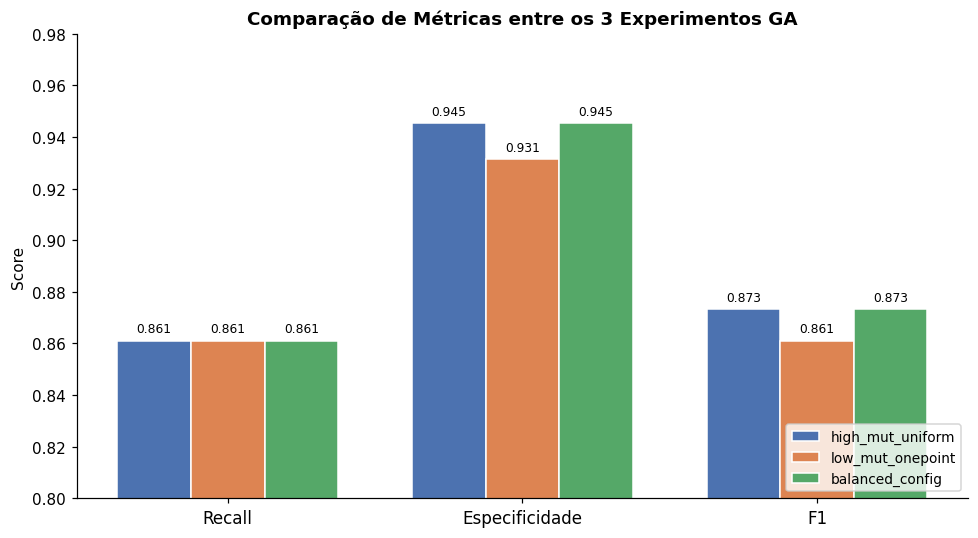

In [7]:
metrics = ['Recall', 'Especificidade', 'F1']
experiments = display_df['Experimento'].tolist()
x = np.arange(len(metrics))
width = 0.25
colors_ga = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(9, 5))
for i, (exp, color) in enumerate(zip(experiments, colors_ga)):
    row = display_df[display_df['Experimento'] == exp].iloc[0]
    vals = [row['Recall'], row['Especificidade'], row['F1']]
    bars = ax.bar(x + i * width, vals, width, label=exp, color=color, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.80, 0.98)
ax.set_ylabel('Score')
ax.set_title('Comparação de Métricas entre os 3 Experimentos GA', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Comparativo: Baseline vs. Modelos Otimizados

In [8]:
baseline_recall = ga_results['baseline_recall'].iloc[0]
baseline_spec   = ga_results['baseline_specificity'].iloc[0]
baseline_f1     = ga_results['baseline_f1'].iloc[0]
baseline_disp   = ga_results['baseline_disparity'].iloc[0]

best_row = ga_results.sort_values('best_fitness', ascending=False).iloc[0]

comparison = pd.DataFrame({
    'Métrica':       ['Recall', 'Especificidade', 'F1-Score', 'Disparidade Demográfica'],
    'Baseline (LR)': [baseline_recall, baseline_spec, baseline_f1, baseline_disp],
    'GA (melhor)':   [best_row['test_recall'], best_row['test_specificity'],
                      best_row['test_f1'], best_row['test_disparity']],
})
comparison['Delta'] = comparison['GA (melhor)'] - comparison['Baseline (LR)']
comparison['Delta (%)'] = (comparison['Delta'] / comparison['Baseline (LR)'] * 100).round(2)
for col in ['Baseline (LR)', 'GA (melhor)', 'Delta']:
    comparison[col] = comparison[col].round(4)

print(f'Melhor experimento GA: {best_row["exp_id"]}\n')
print(comparison.to_string(index=False))

Melhor experimento GA: high_mut_uniform

                Métrica  Baseline (LR)  GA (melhor)   Delta  Delta (%)
                 Recall         0.8333       0.8611  0.0278       3.33
         Especificidade         0.9041       0.9452  0.0411       4.55
               F1-Score         0.8219       0.8732  0.0513       6.24
Disparidade Demográfica         0.0390       0.0065 -0.0325     -83.33


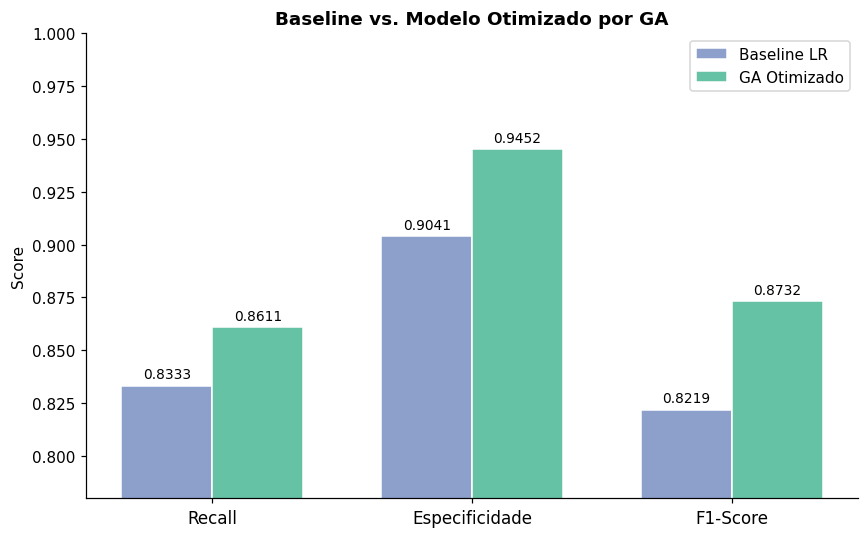

In [9]:
plot_metrics = ['Recall', 'Especificidade', 'F1-Score']
comp_plot = comparison[comparison['Métrica'].isin(plot_metrics)]

x = np.arange(len(plot_metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))

b1 = ax.bar(x - width/2, comp_plot['Baseline (LR)'], width, label='Baseline LR', color='#8DA0CB', edgecolor='white')
b2 = ax.bar(x + width/2, comp_plot['GA (melhor)'],   width, label='GA Otimizado', color='#66C2A5', edgecolor='white')

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(plot_metrics, fontsize=11)
ax.set_ylim(0.78, 1.00)
ax.set_ylabel('Score')
ax.set_title('Baseline vs. Modelo Otimizado por GA', fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

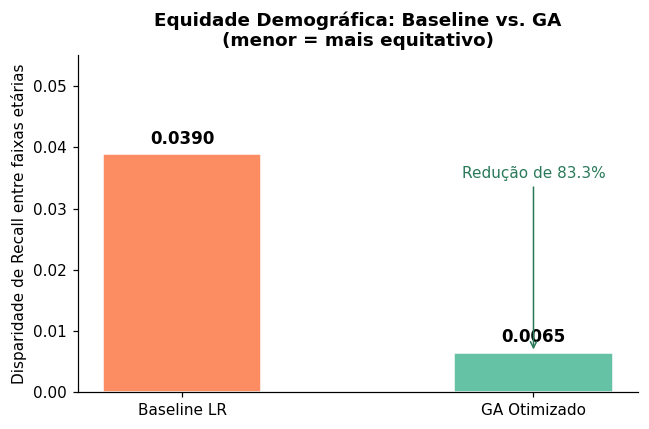

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ['Baseline LR', 'GA Otimizado']
disp_vals = [baseline_disp, best_row['test_disparity']]
colors_disp = ['#FC8D62', '#66C2A5']
bars = ax.bar(labels, disp_vals, color=colors_disp, edgecolor='white', width=0.45)
for bar, val in zip(bars, disp_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Disparidade de Recall entre faixas etárias')
ax.set_title('Equidade Demográfica: Baseline vs. GA\n(menor = mais equitativo)', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, 0.055)
reduction = (1 - best_row['test_disparity'] / baseline_disp) * 100
ax.annotate(f'Redução de {reduction:.1f}%', xy=(1, best_row['test_disparity']),
            xytext=(1, 0.035), ha='center', fontsize=10, color='#2a7a5a',
            arrowprops=dict(arrowstyle='->', color='#2a7a5a'))
plt.tight_layout()
plt.show()

### 3.1 Curvas ROC — Baseline vs. GA

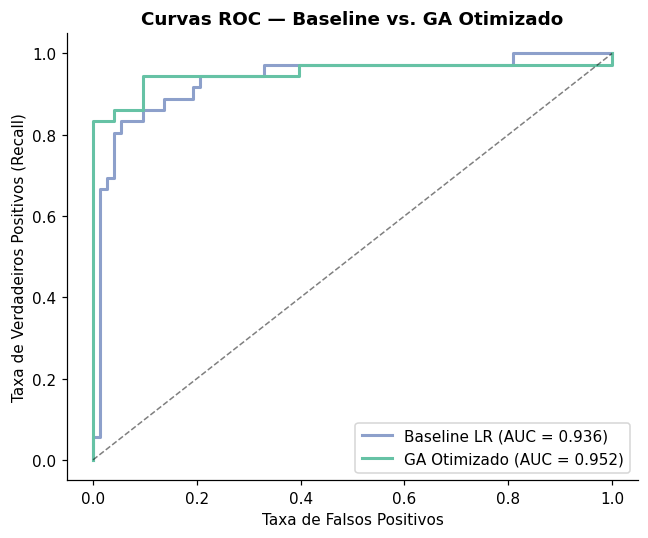

In [11]:
baseline_lr = joblib.load(MODELS_DIR / 'baseline_lr.joblib')
ga_payload  = joblib.load(MODELS_DIR / f'ga_{best_row["exp_id"]}.joblib')
ga_pipeline = ga_payload['pipeline']

probs_baseline = baseline_lr.predict_proba(X_test)[:, 1]
probs_ga       = ga_pipeline.predict_proba(X_test)[:, 1]

fpr_b, tpr_b, _ = roc_curve(y_test, probs_baseline)
fpr_g, tpr_g, _ = roc_curve(y_test, probs_ga)
auc_b = auc(fpr_b, tpr_b)
auc_g = auc(fpr_g, tpr_g)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_b, tpr_b, color='#8DA0CB', lw=2, label=f'Baseline LR (AUC = {auc_b:.3f})')
ax.plot(fpr_g, tpr_g, color='#66C2A5', lw=2, label=f'GA Otimizado (AUC = {auc_g:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos (Recall)')
ax.set_title('Curvas ROC — Baseline vs. GA Otimizado', fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### 3.2 Matrizes de Confusão

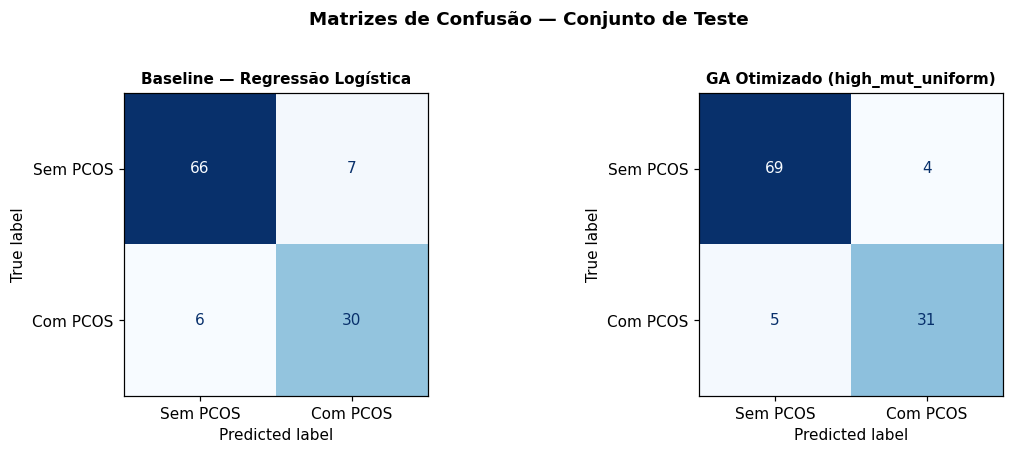

In [12]:
ga_threshold = float(ga_payload.get('threshold', 0.5))
preds_baseline = baseline_lr.predict(X_test)
preds_ga = (probs_ga >= ga_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, preds, title in zip(
    axes,
    [preds_baseline, preds_ga],
    ['Baseline — Regressão Logística', f'GA Otimizado ({best_row["exp_id"]})']
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Sem PCOS', 'Com PCOS'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold', fontsize=10)

plt.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Integração com LLM — Geração de Explicações Clínicas

### 4.1 Pipeline de integração

```
Paciente (dados anonimizados)
        │
        ▼
  Modelo GA (predict_proba)
        │
        ├── probabilidade de PCOS
        ├── predição binária (threshold ótimo)
        └── top-5 features locais (coef × valor normalizado)
        │
        ▼
  Prompt Engineering (contexto clínico + dados)
        │
        ▼
  OpenAI API (gpt-4.1-mini) | fallback local
        │
        ▼
  Explicação em 4 seções → Avaliação qualitativa
```

### 4.2 Resultados reais — 8 pacientes (execução com OpenAI API)

In [13]:
llm_files = sorted(LLM_OUTPUTS_DIR.glob('llm_responses_*.csv'))
llm_df = pd.read_csv(llm_files[-1])

print(f'Arquivo carregado: {llm_files[-1].name}')
print(f'Modo de execução : {llm_df["mode"].iloc[0]}')
print(f'Modelo utilizado : {llm_df["model_file"].iloc[0]}')
print(f'Pacientes gerados: {len(llm_df)}')
print()
summary_cols = ['patient_id', 'predicted_label', 'predicted_probability_pcos',
                'ground_truth_label', 'medical_precision', 'cultural_sensitivity',
                'language_adequacy', 'overall']
summary = llm_df[summary_cols].copy()
summary['predicted_probability_pcos'] = summary['predicted_probability_pcos'].round(3)
summary['predicted_label'] = summary['predicted_label'].map({0: 'Não PCOS', 1: 'PCOS'})
summary['ground_truth_label'] = summary['ground_truth_label'].map({0: 'Não PCOS', 1: 'PCOS'})
summary.columns = ['Paciente', 'Predição', 'Prob. PCOS', 'Real', 'Precisão Med.', 'Sensib. Cultural', 'Adequação Ling.', 'Overall']
print(summary.to_string(index=False))

Arquivo carregado: llm_responses_20260527T144123Z.csv
Modo de execução : openai_api
Modelo utilizado : ga_high_mut_uniform.joblib
Pacientes gerados: 8

Paciente Predição  Prob. PCOS     Real  Precisão Med.  Sensib. Cultural  Adequação Ling.  Overall
   P_001 Não PCOS       0.037     PCOS              4                 3                4        4
   P_002 Não PCOS       0.348 Não PCOS              4                 3                4        4
   P_003 Não PCOS       0.325 Não PCOS              4                 3                4        4
   P_004     PCOS       0.937     PCOS              4                 3                4        4
   P_005 Não PCOS       0.072 Não PCOS              4                 4                4        4
   P_006     PCOS       0.953     PCOS              4                 4                4        4
   P_007 Não PCOS       0.370     PCOS              4                 3                4        4
   P_008 Não PCOS       0.305 Não PCOS              4           

### 4.3 Avaliação qualitativa das respostas LLM

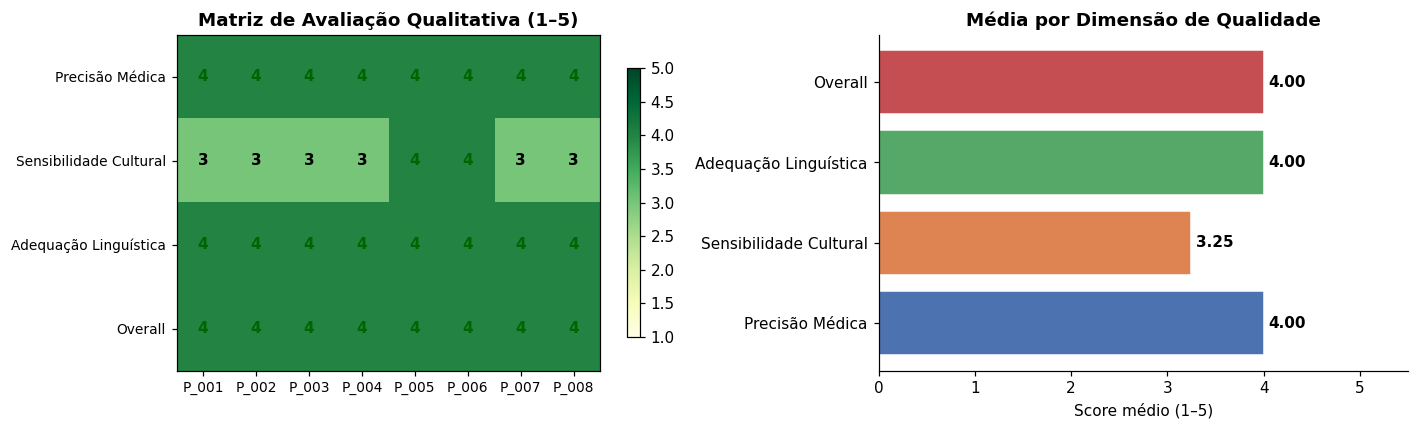

Score overall médio: 4.00/5.0


In [14]:
qual_files = sorted(LLM_OUTPUTS_DIR.glob('llm_qualitative_matrix_*.csv'))
qual_df = pd.read_csv(qual_files[-1])

dimensions = ['medical_precision', 'cultural_sensitivity', 'language_adequacy', 'overall']
dim_labels  = ['Precisão Médica', 'Sensibilidade Cultural', 'Adequação Linguística', 'Overall']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Heatmap de scores
ax = axes[0]
matrix = qual_df[dimensions].values.T
im = ax.imshow(matrix, cmap='YlGn', vmin=1, vmax=5, aspect='auto')
ax.set_xticks(range(len(qual_df)))
ax.set_xticklabels(qual_df['patient_id'], fontsize=9)
ax.set_yticks(range(len(dim_labels)))
ax.set_yticklabels(dim_labels, fontsize=9)
for i in range(len(dim_labels)):
    for j in range(len(qual_df)):
        ax.text(j, i, str(matrix[i, j]), ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='black' if matrix[i, j] < 4 else 'darkgreen')
ax.set_title('Matriz de Avaliação Qualitativa (1–5)', fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)

# Médias por dimensão
ax2 = axes[1]
means = [qual_df[d].mean() for d in dimensions]
bar_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = ax2.barh(dim_labels, means, color=bar_colors, edgecolor='white')
ax2.set_xlim(0, 5.5)
for bar, val in zip(bars, means):
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}', va='center', fontsize=10, fontweight='bold')
ax2.set_xlabel('Score médio (1–5)')
ax2.set_title('Média por Dimensão de Qualidade', fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print(f'Score overall médio: {qual_df["overall"].mean():.2f}/5.0')

### 4.4 Exemplo de explicação gerada pelo LLM (P_004 — alta probabilidade de PCOS)

In [15]:
p4 = llm_df[llm_df['patient_id'] == 'P_004'].iloc[0]
print(f'Paciente  : {p4["patient_id"]}')
print(f'Predição  : {"PCOS" if p4["predicted_label"] == 1 else "Não PCOS"}')
print(f'Prob. PCOS: {p4["predicted_probability_pcos"]:.1%}')
print(f'Real      : {"PCOS" if p4["ground_truth_label"] == 1 else "Não PCOS"}')
print(f'Scores    : precisão médica={p4["medical_precision"]}, '
      f'sensib. cultural={p4["cultural_sensitivity"]}, '
      f'adequação ling.={p4["language_adequacy"]}, overall={p4["overall"]}')
print()
print('--- Explicação gerada pela LLM ---')
print(p4['llm_response'])

Paciente  : P_004
Predição  : PCOS
Prob. PCOS: 93.7%
Real      : PCOS
Scores    : precisão médica=4, sensib. cultural=3, adequação ling.=4, overall=4

--- Explicação gerada pela LLM ---
**Interpretação do caso**

A paciente P_004, uma mulher adulta jovem de 32 anos, apresenta uma alta probabilidade (93,7%) de síndrome dos ovários policísticos (SOP), conforme predição do modelo. A classificação binária indica que o modelo identificou características clínicas e laboratoriais compatíveis com SOP. Essa condição é comum e envolve um conjunto de sinais e sintomas relacionados ao desequilíbrio hormonal e alterações no funcionamento ovariano, que podem impactar a saúde reprodutiva e metabólica da paciente.

**Fatores relevantes**

Os principais fatores que contribuíram para essa predição foram:

- **Número elevado de folículos no ovário direito (15) e esquerdo (12):** A presença de múltiplos folículos pequenos é um achado típico da SOP.
- **Escurecimento da pele:** Pode estar relacionado a alt

### 4.5 Exemplo de explicação gerada pelo LLM (P_001 — baixa probabilidade de PCOS)

In [16]:
p1 = llm_df[llm_df['patient_id'] == 'P_001'].iloc[0]
print(f'Paciente  : {p1["patient_id"]}')
print(f'Predição  : {"PCOS" if p1["predicted_label"] == 1 else "Não PCOS"}')
print(f'Prob. PCOS: {p1["predicted_probability_pcos"]:.1%}')
print(f'Real      : {"PCOS" if p1["ground_truth_label"] == 1 else "Não PCOS"}')
print()
print('--- Explicação gerada pela LLM ---')
print(p1['llm_response'])

Paciente  : P_001
Predição  : Não PCOS
Prob. PCOS: 3.7%
Real      : PCOS

--- Explicação gerada pela LLM ---
**Interpretação do caso**  
A paciente jovem adulta apresenta uma baixa probabilidade de Síndrome dos Ovários Policísticos (PCOS), com uma predição do modelo de apenas 3,7% e classificação negativa para PCOS. Isso indica que, com base nos dados clínicos e laboratoriais disponíveis, é improvável que ela tenha essa condição. O modelo considerou características clínicas, hormonais e ultrassonográficas para essa avaliação.

**Fatores relevantes**  
Os principais fatores que contribuíram para essa predição foram:  
- Baixo número de folículos ovarianos em ambos os ovários (1 folículo em cada lado), o que está abaixo do padrão típico de PCOS, que geralmente apresenta múltiplos folículos pequenos.  
- Ausência de ganho de peso recente, crescimento excessivo de pelos, escurecimento da pele ou queda de cabelo, que são sinais clínicos comuns associados à PCOS.  
- Índices hormonais dentro

## 5. Resumo dos Resultados

In [17]:
print('=' * 60)
print('RESUMO DOS RESULTADOS — FASE 2')
print('=' * 60)
print()
print('MODELOS BASELINE (Fase 1):')
print(f'  LR  F1: {meta["test_metrics"]["lr_test_f1"]:.4f}')
print(f'  KNN F1: {meta["test_metrics"]["knn_test_f1"]:.4f}')
print(f'  DT  F1: {meta["test_metrics"]["dt_test_f1"]:.4f}')
print()
print('MELHOR MODELO GA:')
print(f'  Experimento  : {best_row["exp_id"]}')
print(f'  Fitness      : {best_row["best_fitness"]:.4f}')
print(f'  F1-Score     : {best_row["test_f1"]:.4f} (baseline: {baseline_f1:.4f} | delta: +{best_row["delta_f1_vs_baseline"]:.4f})')
print(f'  Recall       : {best_row["test_recall"]:.4f} (baseline: {baseline_recall:.4f} | delta: +{best_row["delta_recall_vs_baseline"]:.4f})')
print(f'  Especific.   : {best_row["test_specificity"]:.4f} (baseline: {baseline_spec:.4f})')
print(f'  Disparidade  : {best_row["test_disparity"]:.4f} (baseline: {baseline_disp:.4f} | redução: {(1 - best_row["test_disparity"] / baseline_disp) * 100:.1f}%)')
print()
print('INTEGRAÇÃO LLM:')
print(f'  Modo         : {llm_df["mode"].iloc[0]}')
print(f'  Pacientes    : {len(llm_df)}')
print(f'  Score médio  : {qual_df["overall"].mean():.2f}/5.0')
print('=' * 60)

RESUMO DOS RESULTADOS — FASE 2

MODELOS BASELINE (Fase 1):
  LR  F1: 0.8219
  KNN F1: 0.7119
  DT  F1: 0.7246

MELHOR MODELO GA:
  Experimento  : high_mut_uniform
  Fitness      : 0.7814
  F1-Score     : 0.8732 (baseline: 0.8219 | delta: +0.0513)
  Recall       : 0.8611 (baseline: 0.8333 | delta: +0.0278)
  Especific.   : 0.9452 (baseline: 0.9041)
  Disparidade  : 0.0065 (baseline: 0.0390 | redução: 83.3%)

INTEGRAÇÃO LLM:
  Modo         : openai_api
  Pacientes    : 8
  Score médio  : 4.00/5.0
